In [1]:
from pydub import AudioSegment
from pydub.playback import play
from os.path import dirname, join as pjoin
from scipy.io import wavfile
import scipy.io

In [2]:
wav_file = AudioSegment.from_file(file = "Env.wav", format = "wav")

play(wav_file)

Input #0, wav, from '/var/folders/m4/vxwythr152b7zh294kkz975w0000gn/T/tmpae72p23y.wav':
  Duration: 00:00:04.00, bitrate: 3072 kb/s
  Stream #0:0: Audio: pcm_s32le ([1][0][0][0] / 0x0001), 48000 Hz, 2 channels, s32, 3072 kb/s


In [3]:
wav_file = pjoin(dirname(scipy.io.__file__), 'tests','data')
wav_fname = pjoin('Env.wav')

In [4]:
fs, data = wavfile.read(wav_fname)
length = data.shape[0] / fs

print(fs,'sampling frequnecy') # sampling frequency
print(length)
print(data.shape[0])

48000 sampling frequnecy
4.0
192000


In [5]:
import matplotlib.pyplot as plt 
import numpy as np 

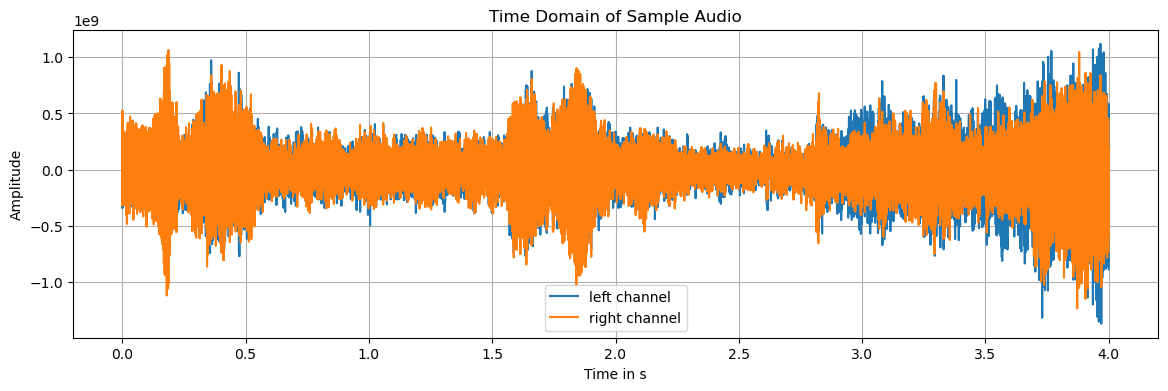

[ 102055168  151573504  186548736 ... -829597440 -883177216 -887844608]
[  52825088  161896704  291942656 ... -478268416 -614342912 -732145920]


In [6]:
f = plt.figure()
f.set_figwidth(14)
f.set_figheight(4)

t = np.linspace(0,length, data.shape[0])
plt.plot(t, data[:, 0], label='left channel') # data[:, 0] all rows, column 0 -> left channel
plt.plot(t, data[:, 1], label='right channel')
plt.ylabel('Amplitude')
plt.xlabel('Time in s')
plt.title('Time Domain of Sample Audio')
plt.legend()
plt.grid()
plt.show()
print(data[:, 0])
print(data[:, 1])

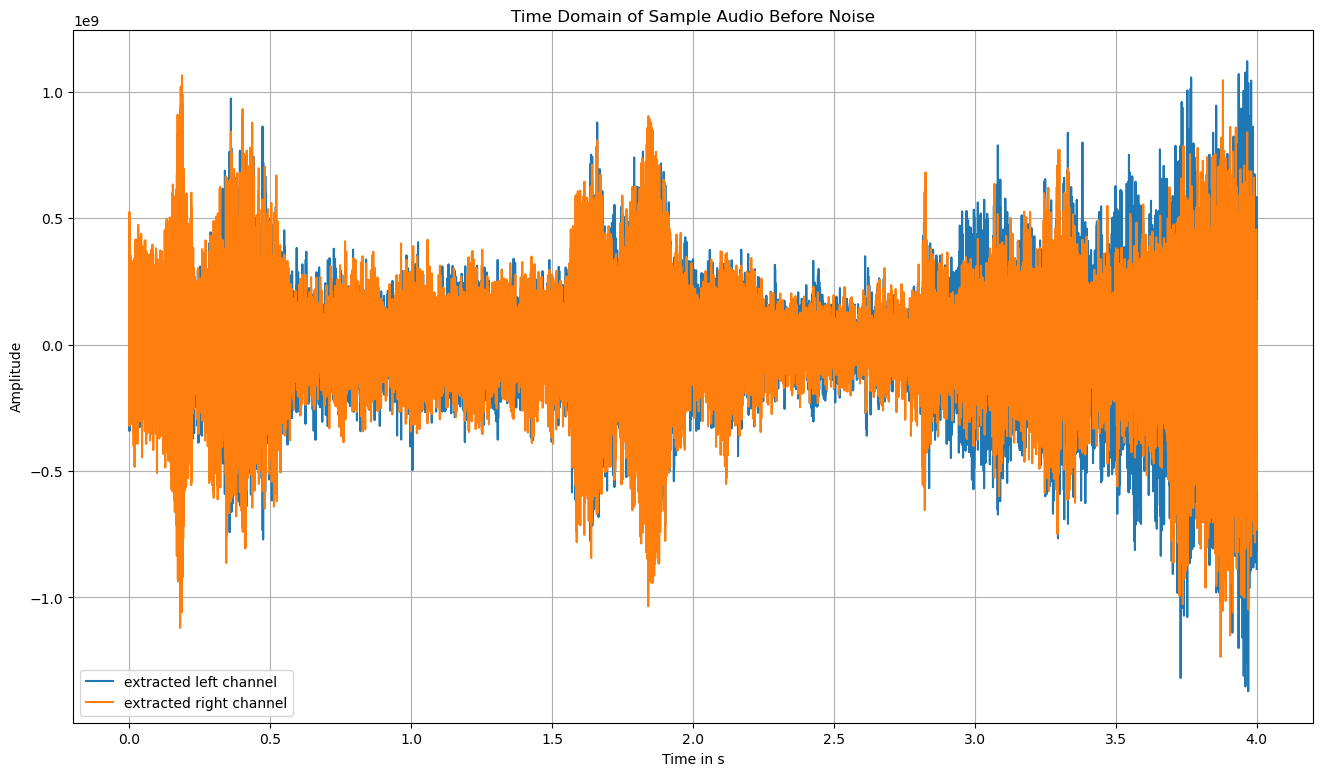

In [7]:
one = 0
two = 4
start = int(one * fs)
end = int(two * fs)
extracted_left = data[start:end, 0] # extracted segment
extracted_right = data[start:end, 1]
extracted_left = extracted_left.astype(np.float64)
extracted_right = extracted_right.astype(np.float64)
t = np.linspace(one,two, len(extracted_left)) 

f = plt.figure()
f.set_figwidth(16)
f.set_figheight(9)

plt.plot(t, extracted_left, label='extracted left channel')
plt.plot(t, extracted_right, label='extracted right channel')  
plt.title('Time Domain of Sample Audio Before Noise')
plt.ylabel('Amplitude')
plt.xlabel('Time in s')
plt.legend()
plt.grid()
plt.show()

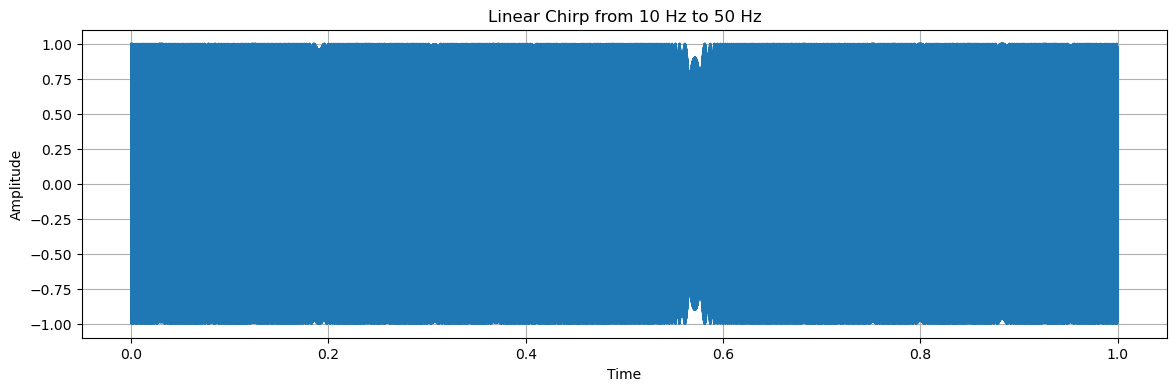

In [8]:
from scipy.signal import chirp

N_audio = len(extracted_left)
duration = length
t_audio = np.arange(N_audio)/fs

x_lin = chirp(t_audio, f0=10000, f1=24000, t1=duration, method='linear')

fg0, ax0 = plt.subplots(figsize=(14,4))
ax0. set_title('Linear Chirp from 10 Hz to 50 Hz')
ax0.set(xlabel='Time', ylabel='Amplitude')
ax0.plot(t_audio[:fs], x_lin[:fs])
ax0.grid(True)
plt.show()

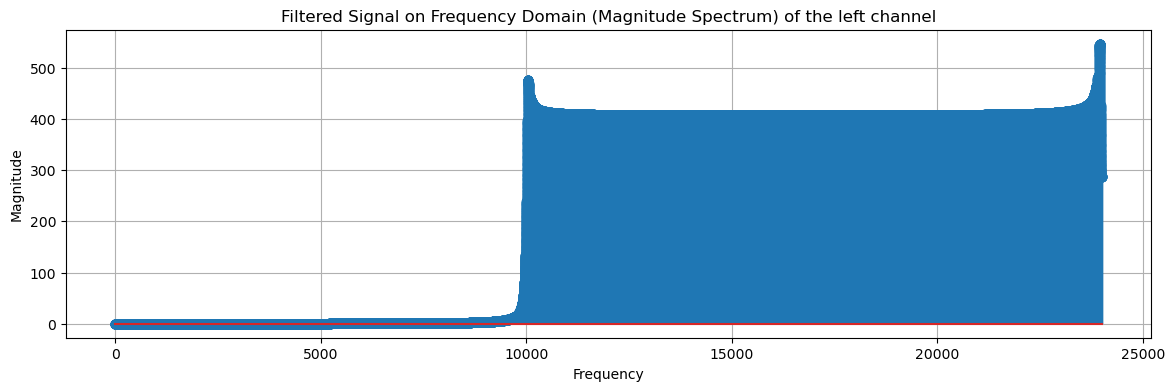

In [9]:
# FFT of the fileterd signal of the left channel
T = 1/fs

fft = np.fft.fft(x_lin)
N = len(x_lin)

freq = np.fft.fftfreq(N, T)
magnitude = np.abs(fft)

f = plt.figure()
f.set_figwidth(14)
f.set_figheight(4)
plt.stem(freq[:N//2], magnitude[:N//2])
plt.ylabel('Magnitude')
plt.xlabel('Frequency')
plt.title('Filtered Signal on Frequency Domain (Magnitude Spectrum) of the left channel')
plt.grid()
plt.show()

#print(N)

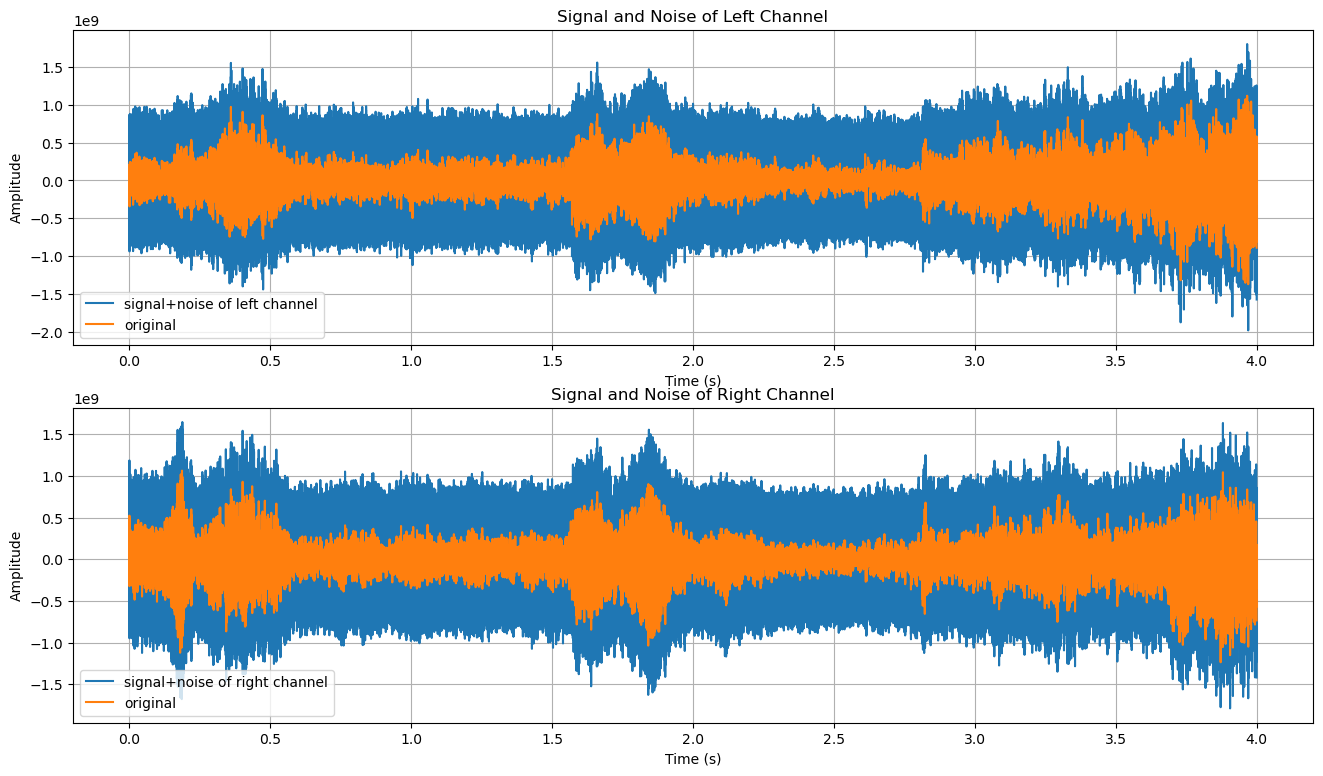

In [10]:
# combination of noise and original signal

#noise_std = 0.05 * np.max(np.abs(extracted_left))  # 10% of max signal
#noise = np.random.normal(0, noise_std, size=len(t))
#noise = np.random.normal(mean, std, size=t)

# Make the chirp peak match 50% of the audio's maximum peak
target_amplitude = 0.5 * np.max(np.abs(extracted_left))
x_lin_scaled = target_amplitude * x_lin

combined_left = x_lin_scaled + extracted_left
combined_right = x_lin_scaled + extracted_right

figsize=(16,9)
plt.figure(figsize=figsize)

plt.subplot(2,1,1)
plt.plot(t_audio, combined_left, label='signal+noise of left channel')
plt.plot(t_audio, extracted_left, label='original')
plt.title('Signal and Noise of Left Channel')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()

plt.subplot(2,1,2)
plt.plot(t_audio, combined_right, label='signal+noise of right channel')
plt.plot(t_audio, extracted_right, label='original')
plt.title('Signal and Noise of Right Channel')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.show()

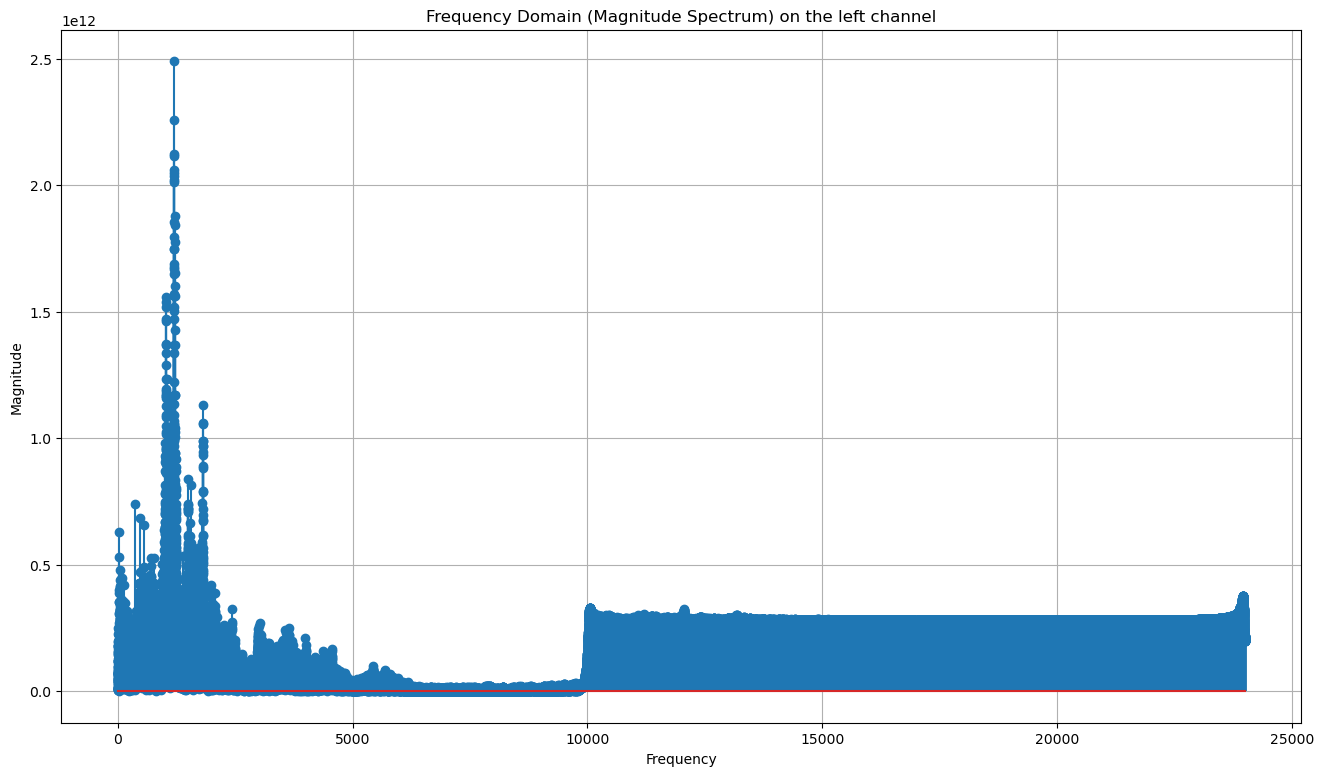

In [11]:
# FFT of the unfiltered signal of the left channel
T = 1/fs

fft = np.fft.fft(combined_left)
N = len(combined_left)

freq = np.fft.fftfreq(N, T)
magnitude = np.abs(fft)

f = plt.figure()
f.set_figwidth(16)
f.set_figheight(9)
plt.stem(freq[:N//2], magnitude[:N//2])
plt.ylabel('Magnitude')
plt.xlabel('Frequency')
plt.title('Frequency Domain (Magnitude Spectrum) on the left channel')
plt.grid()
plt.show()

#print(N)

96000
Numerator Coefficients:  [0.00598855 0.01197709 0.00598855]
Denominator Coefficients:  [ 1.         -1.76947104  0.79342522]


<Figure size 1400x400 with 0 Axes>

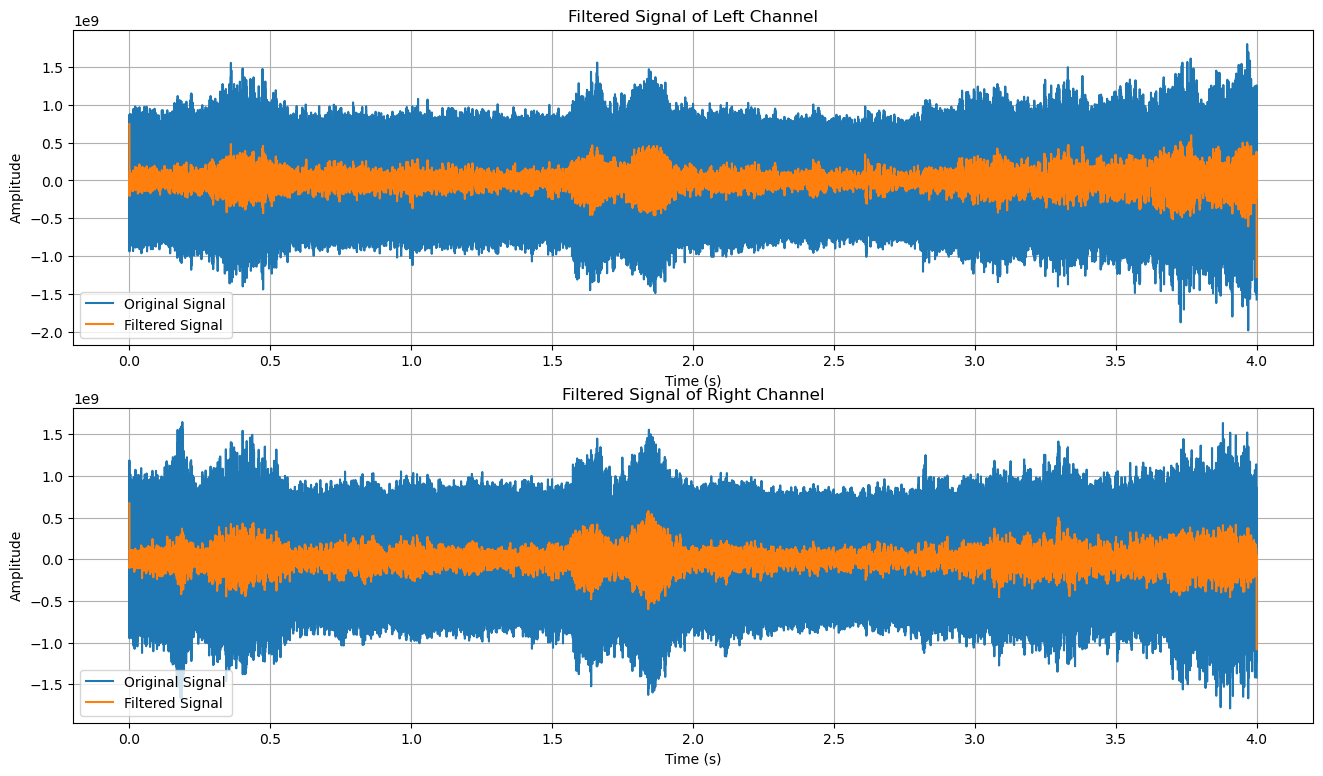

In [12]:
# applying LPF
from scipy.signal import butter,filtfilt

cutoff = 5000 # allowing signals below cutoff, i.e., <cutoff
nyq_freq = 2 * fs
order = 2
n = int(T*fs)
print(nyq_freq)

def butter_lowpass_filter_left(combined_left, cutoff, fs, order):
    normal_cutoff = cutoff/nyq_freq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, combined_left)
    return y, b, a

def butter_lowpass_filter_right(combined_right, cutoff, fs, order):
    normal_cutoff = cutoff/nyq_freq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    x = filtfilt(b, a, combined_right)
    print('Numerator Coefficients: ',b)
    print('Denominator Coefficients: ',a)
    return x

f = plt.figure()
f.set_figwidth(14)
f.set_figheight(4)

y, b, a = butter_lowpass_filter_left(combined_left, cutoff, fs, order)
x = butter_lowpass_filter_right(combined_right, cutoff, fs, order)

figsize=(16,9)
plt.figure(figsize=figsize)

plt.subplot(2,1,1)
plt.plot(t, combined_left, label='Original Signal')
plt.plot(t, y,label='Filtered Signal')
plt.title('Filtered Signal of Left Channel')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()

plt.subplot(2,1,2)
plt.plot(t, combined_right, label='Original Signal')
plt.plot(t, x,label='Filtered Signal')
plt.title('Filtered Signal of Right Channel')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()

plt.show()

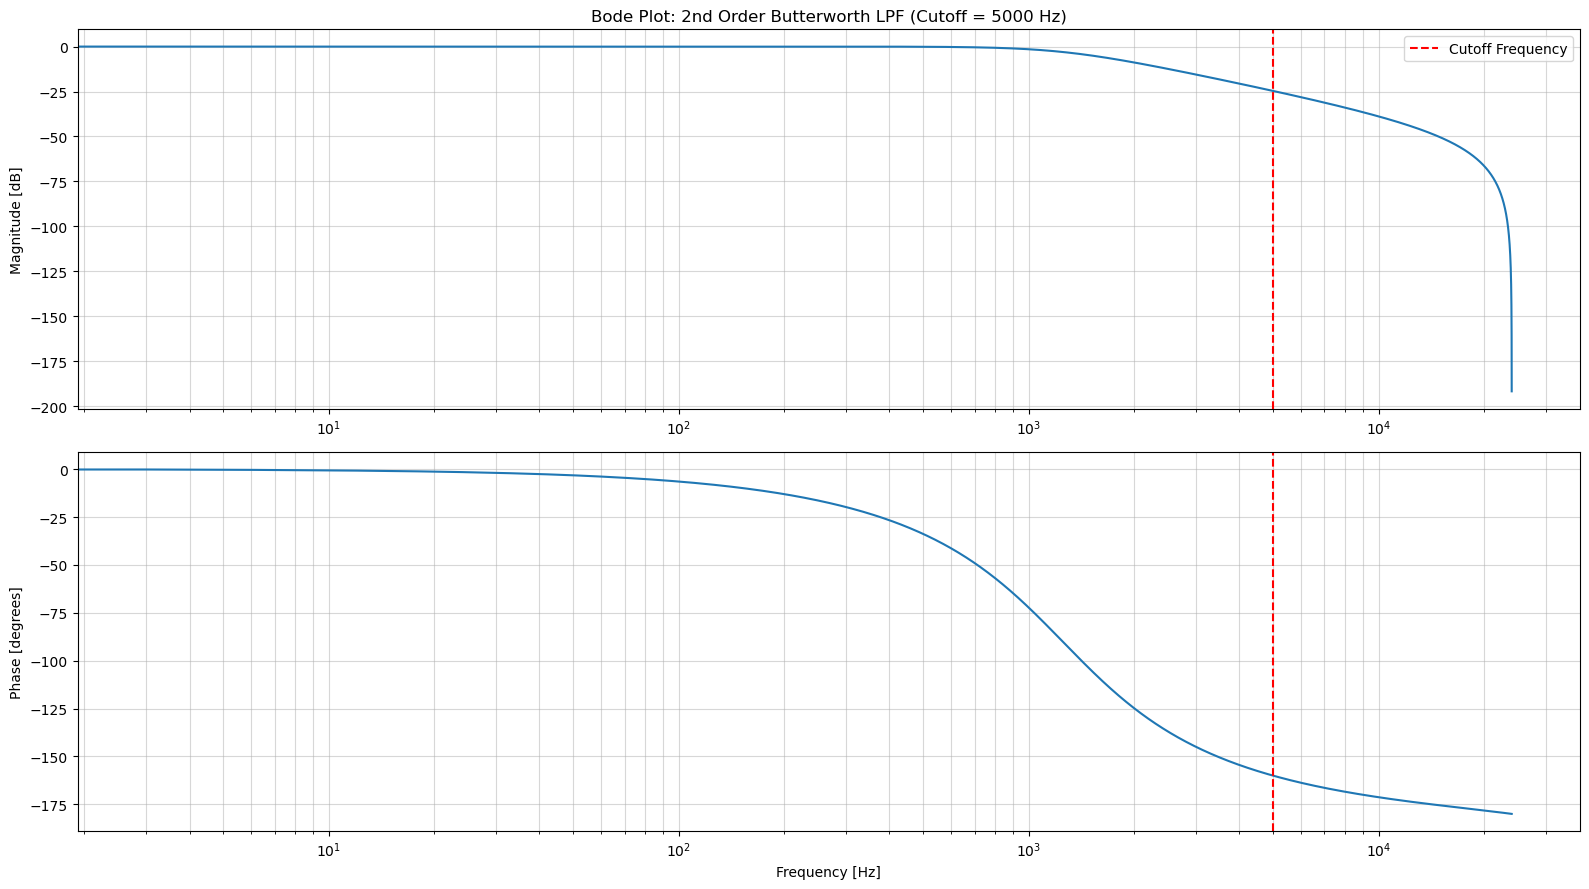

In [13]:
from scipy.signal import freqz

normal_cutoff = cutoff / nyq_freq
b, a = butter(order, normal_cutoff, btype='low', analog=False)

w, h = freqz(b, a, worN=8000, fs=fs)

plt.figure(figsize=(16, 9))

# Magnitude Response
plt.subplot(2, 1, 1)
plt.semilogx(w, 20 * np.log10(np.abs(h)))
plt.title(f'Bode Plot: 2nd Order Butterworth LPF (Cutoff = {cutoff} Hz)')
plt.ylabel('Magnitude [dB]')
plt.axvline(cutoff, color='red', linestyle='--', label='Cutoff Frequency')
plt.grid(True, which="both", alpha=0.5)
plt.legend()

# Phase Response
plt.subplot(2, 1, 2)
plt.semilogx(w, np.angle(h, deg=True))
plt.ylabel('Phase [degrees]')
plt.xlabel('Frequency [Hz]')
plt.axvline(cutoff, color='red', linestyle='--')
plt.grid(True, which="both", alpha=0.5)

plt.tight_layout()
plt.show()

In [14]:
from scipy.signal import tf2zpk

z, p, k = tf2zpk(b, a)

print('Zeros:',z)
print('Poles:',p)
print('Gain:',k)
print()
if np.all(np.abs(p) < 1):
    print('Filter is Stable')

Zeros: [-0.99999999 -1.00000001]
Poles: [0.88473552+0.10328739j 0.88473552-0.10328739j]
Gain: 0.005988546284779564

Filter is Stable


In [15]:
# Signal-to-Noise Ratio

snr_before = 10 * np.log10(np.mean(extracted_left**2) / np.mean((combined_left - extracted_left)**2))
snr_after  = 10 * np.log10(np.mean(extracted_left**2) / np.mean((y - extracted_left)**2))
improvement = snr_after - snr_before

print('SNR Before: ',snr_before)
print('SNR After: ',snr_after)
print('Improvement: ', improvement)

SNR Before:  -7.976095228092028
SNR After:  5.372216615268753
Improvement:  13.348311843360781


In [22]:
from scipy import signal

huh = signal.TransferFunction(a, b)
print(huh)

TransferFunctionContinuous(
array([ 166.98543393, -295.47588915,  132.49045522]),
array([1., 2., 1.]),
dt: None
)


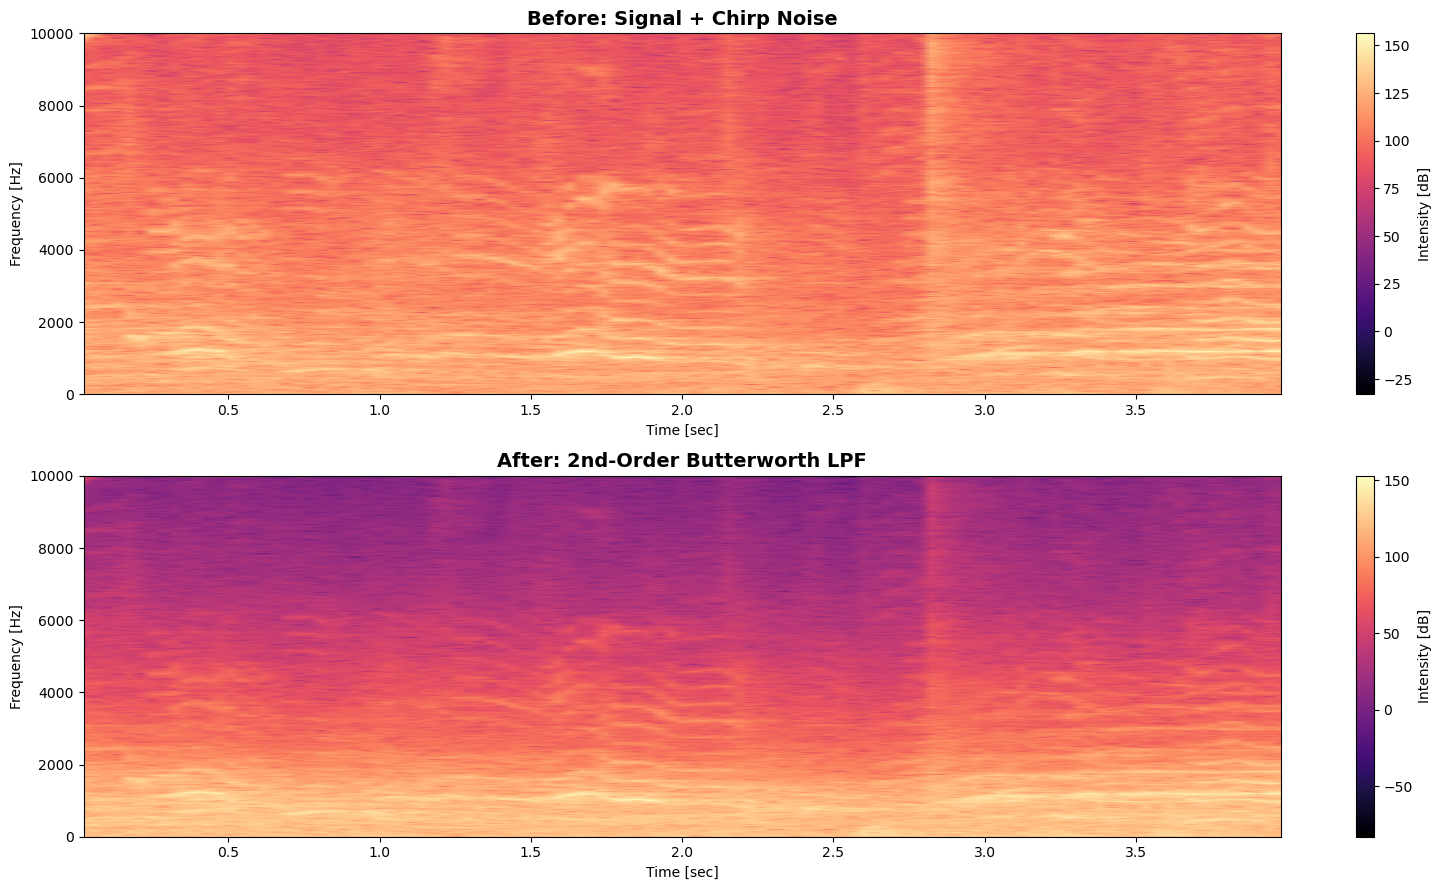

In [29]:
from scipy.signal import spectrogram

def plot_styled_spectrogram(sig, title, fs):
    frequencies, times, Sxx = spectrogram(sig, fs, nperseg=2048)
    
    plt.pcolormesh(times, frequencies, 10 * np.log10(Sxx + 1e-10), shading='gouraud', cmap='magma')
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('Frequency [Hz]')
    plt.xlabel('Time [sec]')
    
    plt.ylim(0, 10000) 
    plt.colorbar(label='Intensity [dB]')

plt.figure(figsize=(16, 9))

plt.subplot(2, 1, 1)
plot_styled_spectrogram(combined_left, "Before: Signal + Chirp Noise", fs)

plt.subplot(2, 1, 2)
plot_styled_spectrogram(y, "After: 2nd-Order Butterworth LPF", fs)

plt.tight_layout()
plt.show()

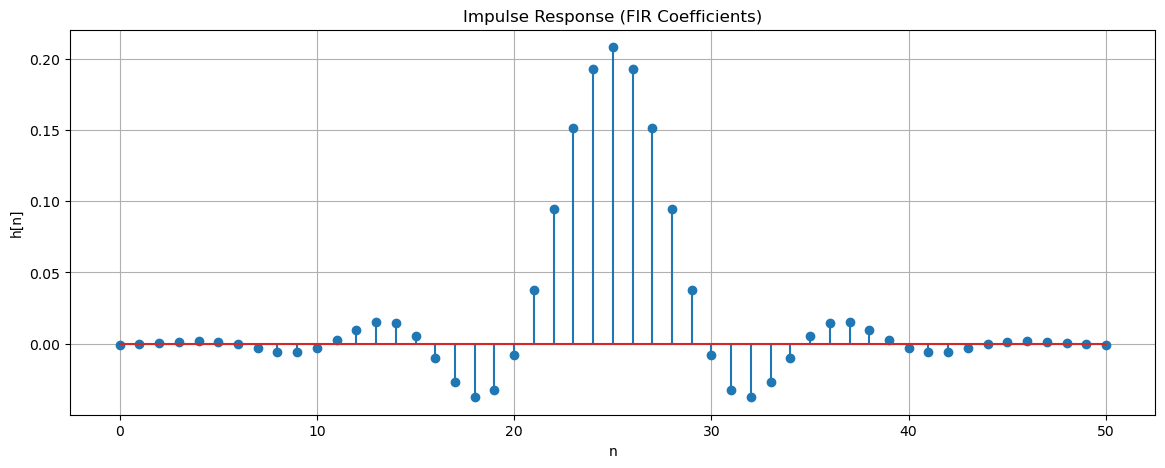

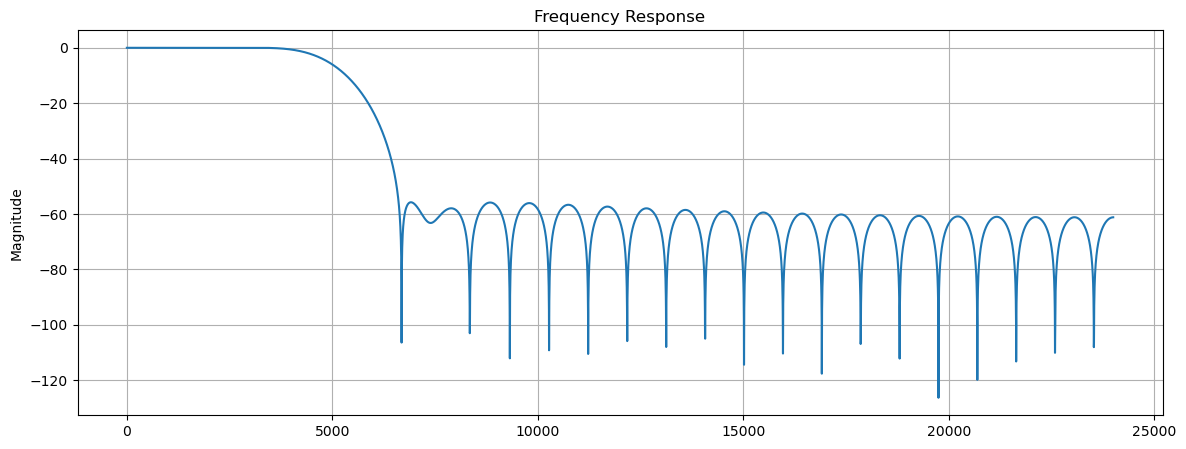

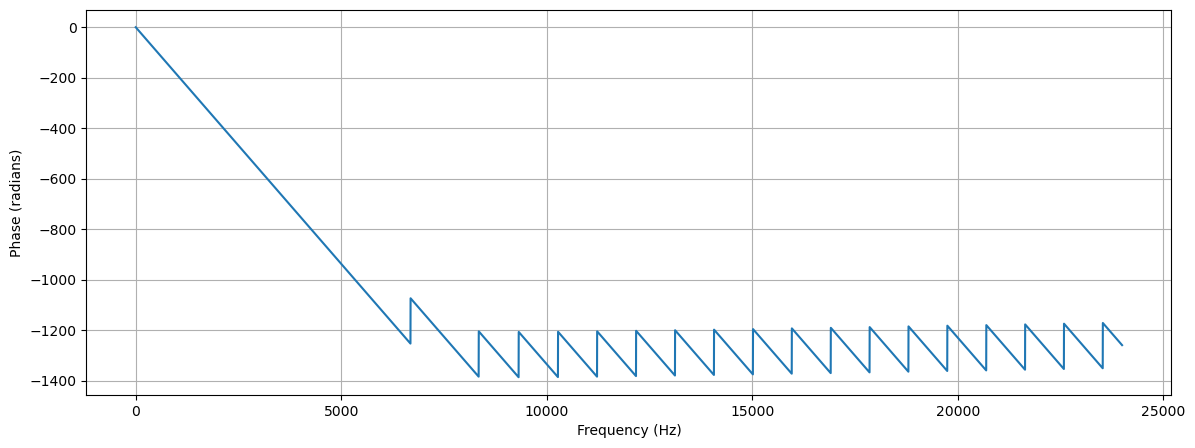

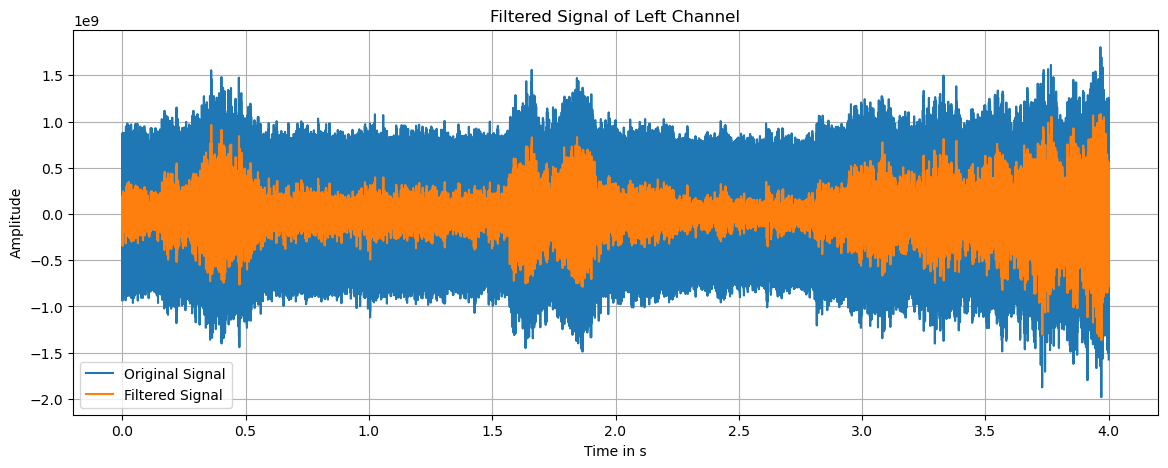

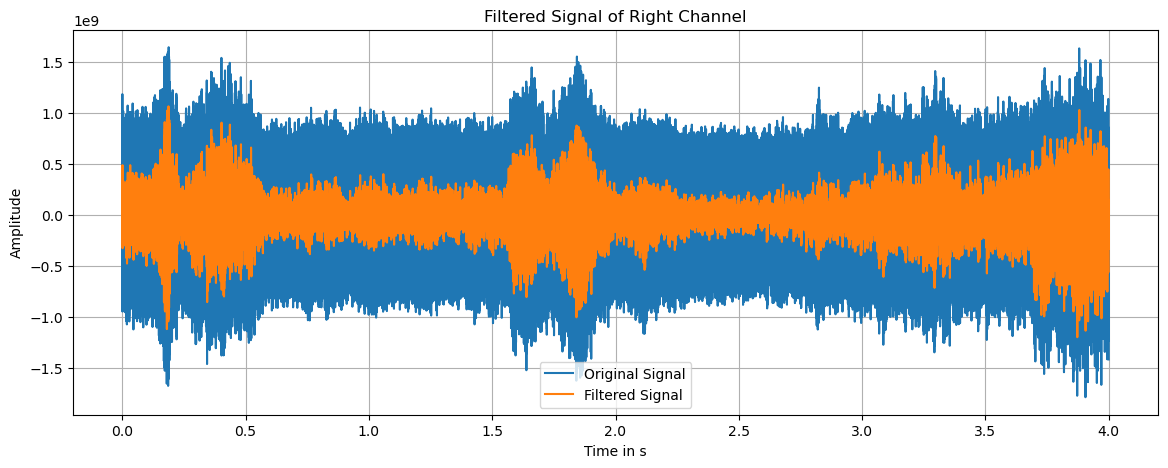

In [16]:
from scipy.signal import firwin, lfilter, freqz

#parameter
fs = fs
cutoff = cutoff 
num_taps = 51 #discrete time steps K. A longer x-axis means the filter "remembers" the input for a longer duration, allowing for a sharper fc.

#filter design
h = firwin(num_taps, cutoff, fs=fs)

t = t
x = combined_left
z = combined_right

yeay = lfilter(h, 1.0, x)
what = lfilter(h, 1.0, z)

plt.figure(figsize=(14, 5))
plt.stem(h)
plt.title("Impulse Response (FIR Coefficients)")
plt.xlabel("n")
plt.ylabel("h[n]")
plt.grid()

w, H = freqz(h, worN=8000, fs=fs)
plt.figure(figsize=(14, 5))
plt.plot(w,20*np.log10(np.abs(H)))
plt.title("Frequency Response")
plt.ylabel("Magnitude")
plt.grid()

plt.figure(figsize=(14, 5))
phase = np.unwrap(np.angle(H))
plt.plot(w, phase * 180 /np.pi)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase (radians)")
plt.grid()

plt.figure(figsize=(14, 5))
plt.plot(t, combined_left, label='Original Signal')
plt.plot(t, yeay,label='Filtered Signal')
plt.title('Filtered Signal of Left Channel')
plt.xlabel('Time in s')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()

plt.figure(figsize=(14, 5))
plt.plot(t, combined_right, label='Original Signal')
plt.plot(t, what,label='Filtered Signal')
plt.title('Filtered Signal of Right Channel')
plt.xlabel('Time in s')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()

plt.show()


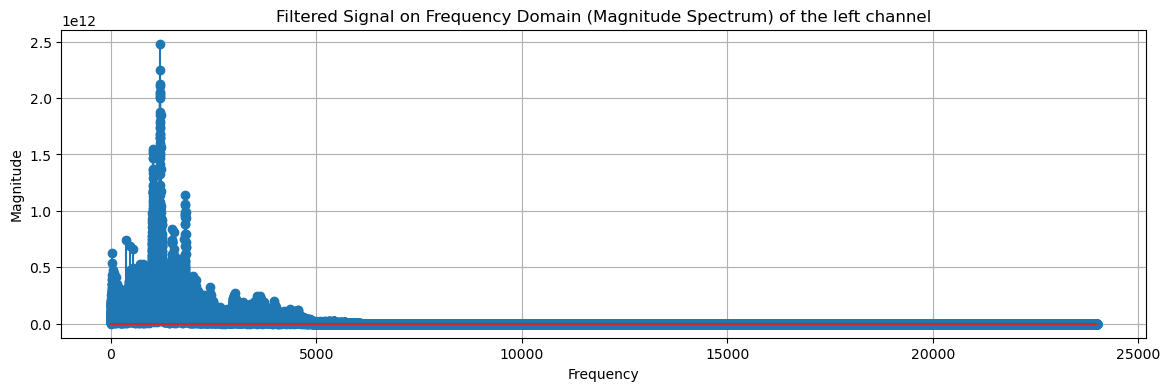

In [17]:
# FFT of the fileterd signal of the left channel
T = 1/fs

fft = np.fft.fft(yeay)
N = len(yeay)

freq = np.fft.fftfreq(N, T)
magnitude = np.abs(fft)

f = plt.figure()
f.set_figwidth(14)
f.set_figheight(4)
plt.stem(freq[:N//2], magnitude[:N//2])
plt.ylabel('Magnitude')
plt.xlabel('Frequency')
plt.title('Filtered Signal on Frequency Domain (Magnitude Spectrum) of the left channel')
plt.grid()
plt.show()

#print(N)

In [18]:
from scipy.io.wavfile import write

stereo = np.column_stack((y, x))

stereo = stereo / np.max(np.abs(stereo))
stereo_int16 = np.int16(stereo * 32767)

write("filtered_stereo.wav", fs, stereo_int16)

In [19]:
delay = (num_taps - 1) // 2
yeay_aligned = yeay[delay:]
extracted_aligned = extracted_left[:len(yeay_aligned)]

snr_after = 10 * np.log10(np.mean(extracted_aligned**2) / np.mean((yeay_aligned - extracted_aligned)**2))
improvement = snr_after - snr_before

print(improvement)

30.163426589136172
